In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA
from scipy.stats import norm
from datetime import datetime

from src.cbr_parser import CBRParser
from src.data_handler import DataHandler
from src.classical_models import ClassicModel
from src.backtest import kupiec_pof, christoffersen, run_horizon_backtest

In [2]:
TENOR_YEARS = {'1W': 7/365, '2W': 14/365, '1M': 30/365, '2M': 60/365, '3M': 90/365, '6M': 180/365, '1Y': 1.0, '2Y': 2.0}
maturities = list(TENOR_YEARS.values())[:-1]
tenors = list(TENOR_YEARS.keys())

ROISFIX = DataHandler.from_excel('data/roisfix.xlsx').clean()

### Exploratory Data Analysis

In [3]:
ROISFIX.descriptive_statistics(caption='ROISfix Descriptive Statistics', style=True)

,1W,2W,1M,2M,3M,6M,1Y,2Y
count,3708.0000,3708.0000,3708.0000,3708.0000,3708.0000,3708.0000,2499.0000,995.0000
mean,9.4823,9.5115,9.5552,9.5882,9.6098,9.6587,10.5029,13.7736
std,4.6535,4.6731,4.7193,4.7321,4.7323,4.7512,4.9774,4.1968
min,3.0800,3.0900,3.1800,3.2400,3.3000,3.4900,4.1400,8.3500
25%,6.1000,6.1000,6.0900,6.0800,6.0875,6.1000,7.1500,9.2450
50%,7.6300,7.6300,7.6700,7.7400,7.8200,7.9800,8.5000,13.5900
75%,11.2325,11.2200,11.2200,11.2000,11.1725,11.0700,14.4000,16.7550
max,22.8500,23.9200,25.1500,25.0600,25.1800,26.7100,26.5300,25.2000
skew,1.0596,1.0733,1.1137,1.1375,1.1624,1.2435,1.1352,0.5793
kurtosis,0.1351,0.1757,0.3206,0.4125,0.5123,0.8565,0.5426,-0.3301


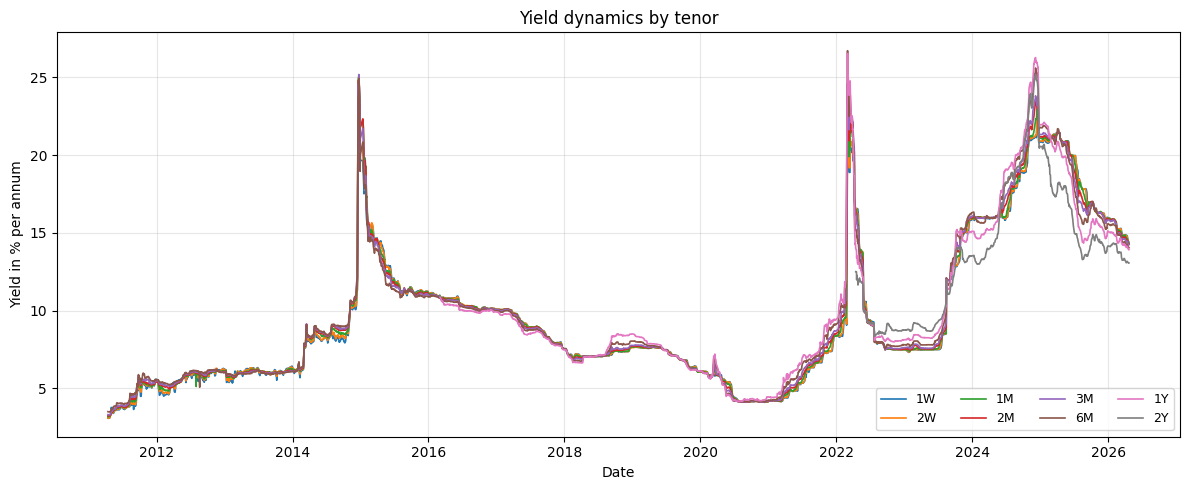

In [4]:
ROISFIX.plot_time_series()

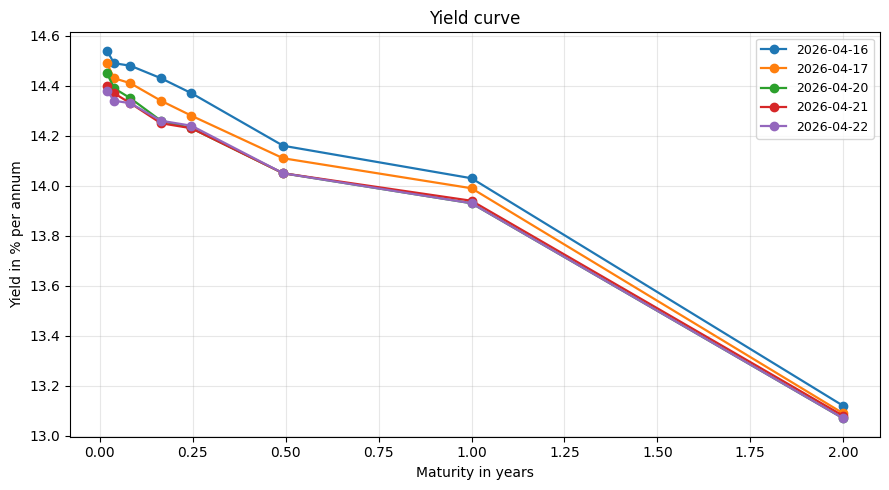

In [5]:
ROISFIX.plot_yield_curves(dates=None)

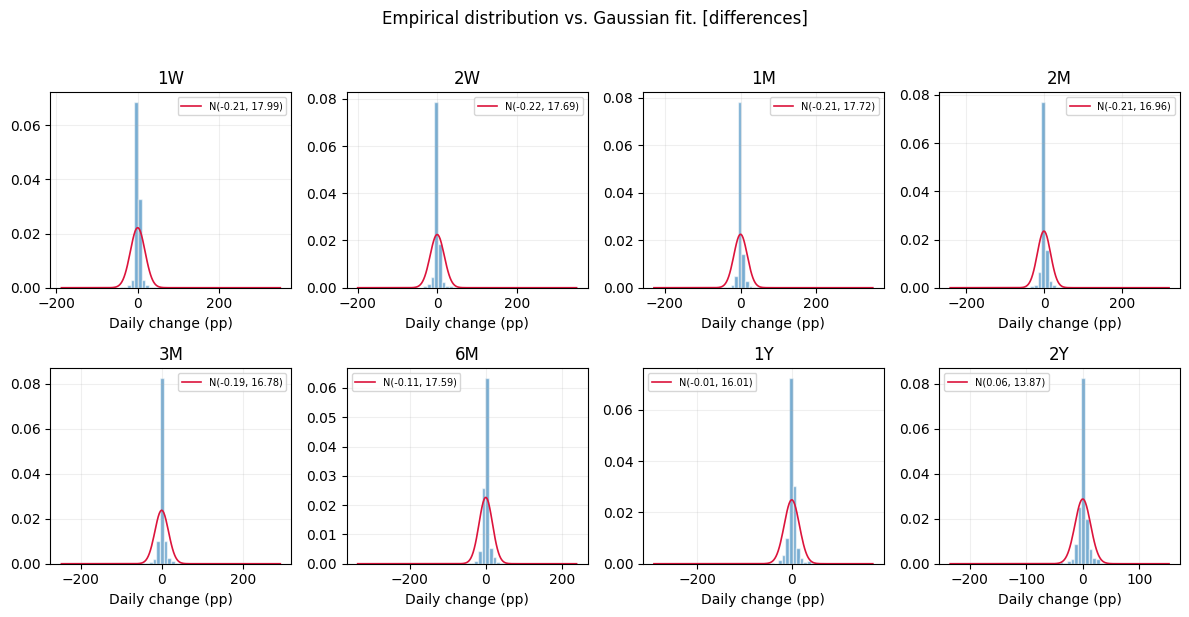

In [6]:
ROISFIX.plot_distributions(which='differences')

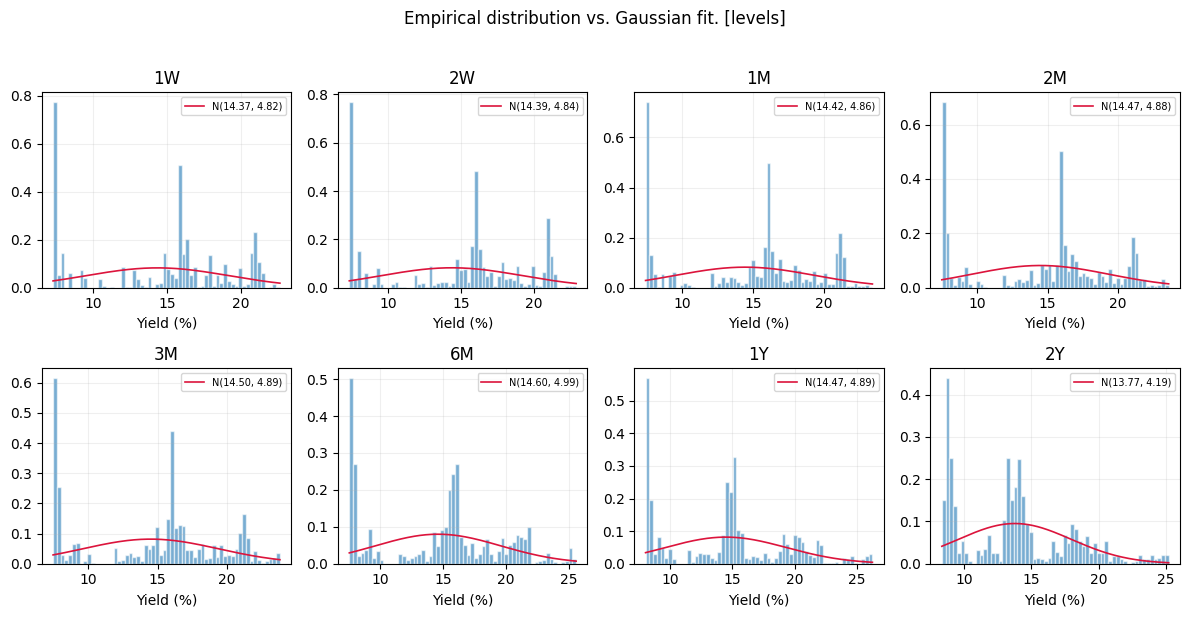

In [7]:
ROISFIX.plot_distributions(which='levels')

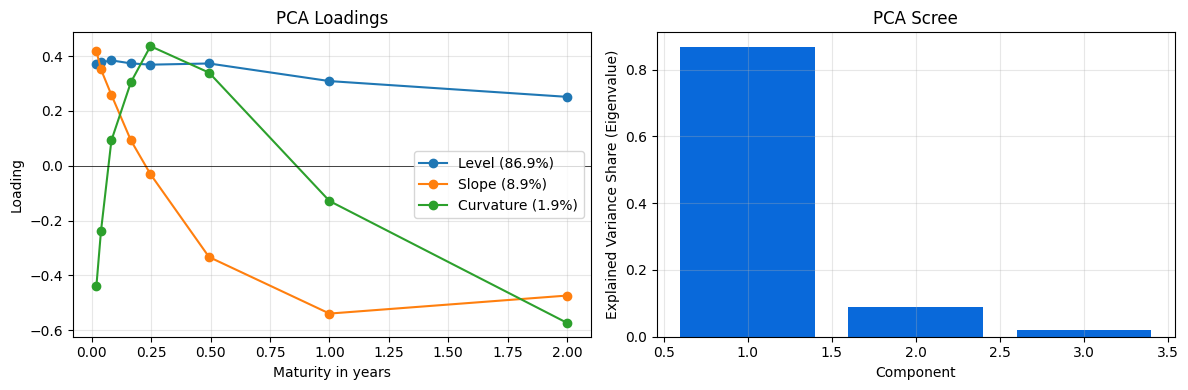

In [8]:
ROISFIX.plot_pca_decomposition(n_components=3)

### Classical Models: Calibration

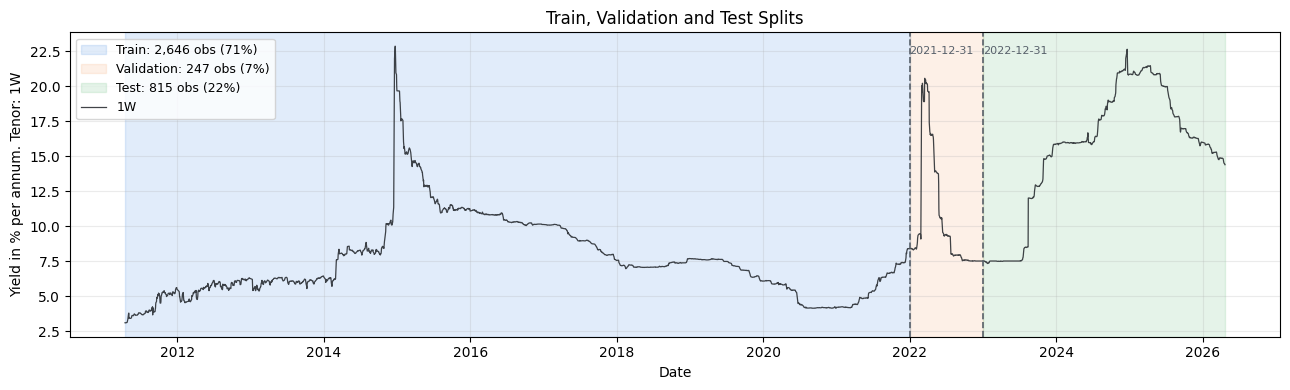

In [9]:
train, val, test = ROISFIX.train_val_test_split(train_end='2021-12-31', val_end='2022-12-31', plot=True)
train = train.drop(columns=['2Y'])

In [10]:
vasicek = ClassicModel('vasicek').calibrate(train['1M']) # fits one tenor
vasicek.display_params()

kappa,0.489338
theta,8.5964
sigma,2.4638
r0,8.3700


In [11]:
hw = ClassicModel('hull-white').calibrate(train['1M']) # fits one tenor
hw.display_params()

a,0.489338
sigma,2.4638
theta_t (summary),"len=2646, mean=4.2060, std=34.5151"
r0,8.3700


In [12]:
ns = ClassicModel('nelson-siegel').calibrate(train.iloc[-1], taus=maturities) # fits the last row
ns.display_params()

beta0,-73.0905
beta1,81.3730
beta2,100.0000
lambda,0.213485


In [13]:
dns = ClassicModel('dns').calibrate(train, taus=maturities) # fits whole matrix
dns.display_params()

lambda,0.730800
mu,"[0.1981, -0.2010, -0.2069]"
A (summary),"len=9, mean=0.3337, std=0.4635"
Sigma (summary),"len=9, mean=0.2214, std=1.3811"
beta_last,"[6.6882, 1.5927, 7.1852]"
r0,8.3800


### Classical Models: Simulation

In [14]:
NPATHS = 10_000 # num. of simulations
DT = 1/(250 * 5)
T = 1/250 # for simulation of 1 year, 250 business days (M)

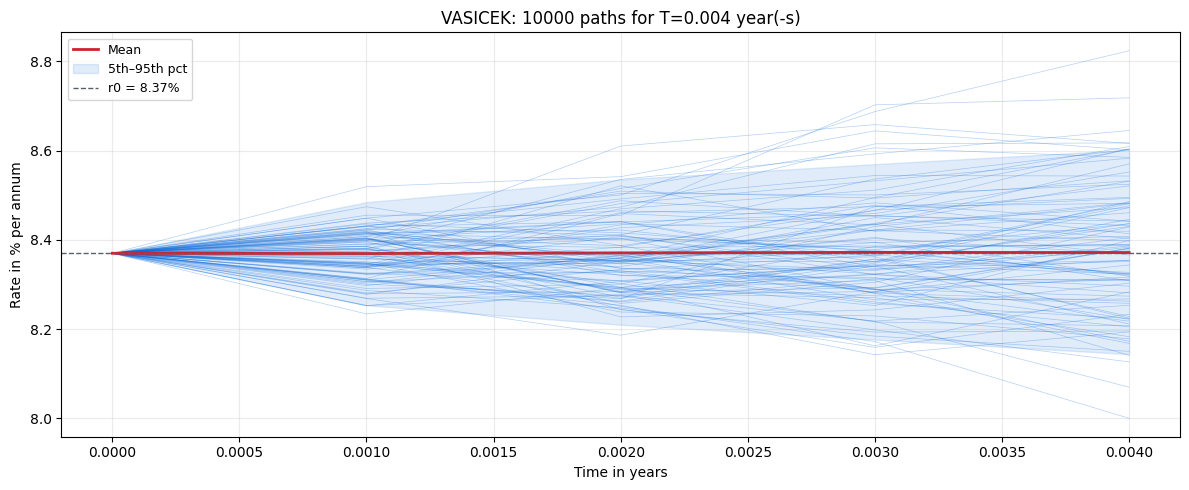

In [15]:
paths_vasicek = vasicek.simulate(T=T, dt=DT, n_paths=NPATHS, n_show=100)

In [16]:
paths_vasicek

,path_1,path_2,path_3,path_4,path_5,path_6,path_7,path_8,path_9,path_10,path_11,path_12,path_13,path_14,path_15,path_16,path_17,path_18,path_19,path_20,path_21,path_22,path_23,path_24,path_25,path_26,path_27,path_28,path_29,path_30,path_31,path_32,path_33,path_34,path_35,path_36,path_37,path_38,path_39,path_40,...,path_9961,path_9962,path_9963,path_9964,path_9965,path_9966,path_9967,path_9968,path_9969,path_9970,path_9971,path_9972,path_9973,path_9974,path_9975,path_9976,path_9977,path_9978,path_9979,path_9980,path_9981,path_9982,path_9983,path_9984,path_9985,path_9986,path_9987,path_9988,path_9989,path_9990,path_9991,path_9992,path_9993,path_9994,path_9995,path_9996,path_9997,path_9998,path_9999,path_10000
0,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,...,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000,8.370000
1,8.391323,8.297615,8.422385,8.435634,8.234127,8.279344,8.378997,8.348051,8.368918,8.310643,8.431371,8.424291,8.374690,8.448643,8.402668,8.310207,8.395786,8.303267,8.431305,8.366609,8.357206,8.322637,8.455284,8.359320,8.340240,8.345549,8.407184,8.395555,8.398851,8.400111,8.519334,8.341767,8.334392,8.313379,8.413014,8.448763,8.362148,8.311541,8.312633,8.415427,...,8.370592,8.350899,8.415641,8.444997,8.364005,8.353314,8.406515,8.352226,8.346396,8.442364,8.457879,8.445627,8.358365,8.220973,8.359761,8.317267,8.361048,8.323322,8.368643,8.297665,8.280839,8.455294,8.302516,8.370112,8.436606,8.433804,8.425479,8.391195,8.420542,8.465775,8.399707,8.242059,8.333257,8.418617,8.326388,8.482989,8.365686,8.376029,8.448469,8.357346
2,8.403688,8.360389,8.319855,8.415815,8.292050,8.284039,8.481337,8.238326,8.251236,8.364392,8.491771,8.410891,8.402679,8.500632,8.346028,8.261061,8.409086,8.366385,8.350118,8.352905,8.340280,8.351870,8.454733,8.321372,8.427349,8.308068,8.386902,8.284727,8.349198,8.436152,8.541706,8.383645,8.372891,8.458977,8.360970,8.335968,8.289030,8.262617,8.244846,8.422024,...,8.389801,8.503223,8.355129,8.367171,8.389590,8.378674,8.430161,8.365271,8.302723,8.338914,8.477665,8.356306,8.262499,8.194595,8.389865,8.455898,8.429382,8.423306,8.414284,8.323346,8.455584,8.363164,8.273834,8.346843,8.498938,8.365659,8.478747,8.431669,8.477291,8.521243,8.506985,8.238769,8.370305,8.367358,8.259260,8.606019,8.309182,8.420807,8.485533,8.439321
3,8.288208,8.422587,8.315919,8.374080,8.274690,8.356411,8.532340,8.229552,8.171990,8.290019,8.544289,8.321922,8.394521,8.687505,8.378152,8.312917,8.335219,8.280948,8.405673,8.333324,8.422166,8.361940,8.702621,8.288565,8.454532,8.252840,8.465876,8.322516,8.289281,8.421073,8.644295,8.477925,8.281382,8.433527,8.494959,8.331389,8.308901,8.341280,8.159118,8.363577,...,8.346625,8.513333,8.281494,8.510094,8.429696,8.433545,8.526172,8.436181,8.305034,8.326125,8.567488,8.358249,8.210433,8.331801,8.324723,8.335066,8.498631,8.372415,8.444676,8.450089,8.359830,8.360404,8.377335,8.394459,8.486445,8.532259,8.472151,8.459390,8.592276,8.589626,8.599127,8.176223,8.455981,8.379266,8.207421,8.621482,8.322552,8.551057,8.512148,8.384970
4,8.217846,8.419352,8.222205,8.324316,8.257799,8.327105,8.583021,8.178279,8.000030,8.172662,8.543068,8.281136,8.308420,8.823948,8.435990,8.308957,8.351579,8.262595,8.318373,8.405255,8.481561,8.224238,8.718359,8.312158,8.432168,8.399126,8.604517,8.296316,8.273873,8.397429,8.601674,8.413806,8.316827,8.570278,8.603019,8.386488,8.141269,8.211445,8.233448,8.476517,...,8.403059,8.52

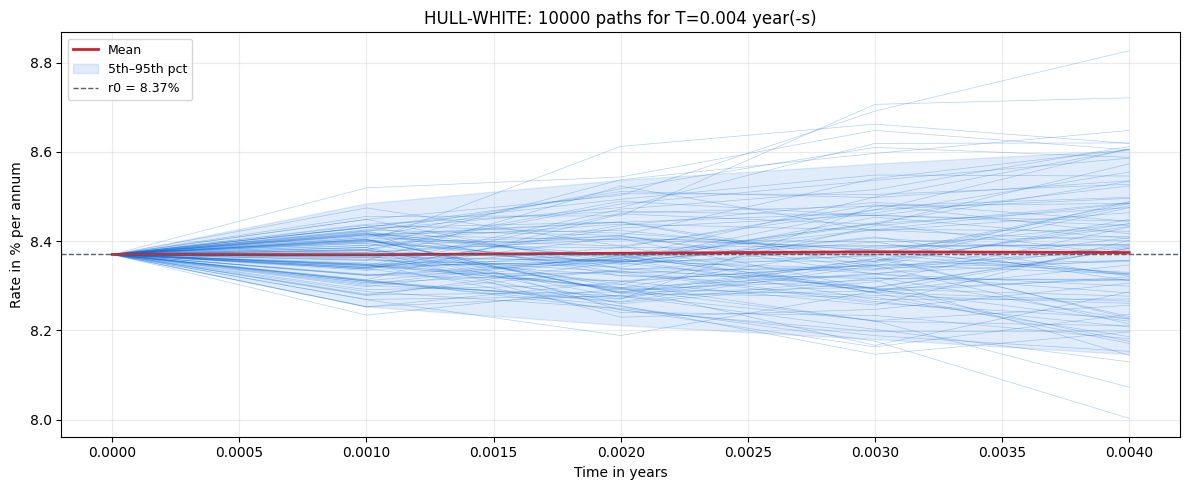

In [17]:
paths_hw = hw.simulate(T=T, dt=DT, n_paths=NPATHS, n_show=100)

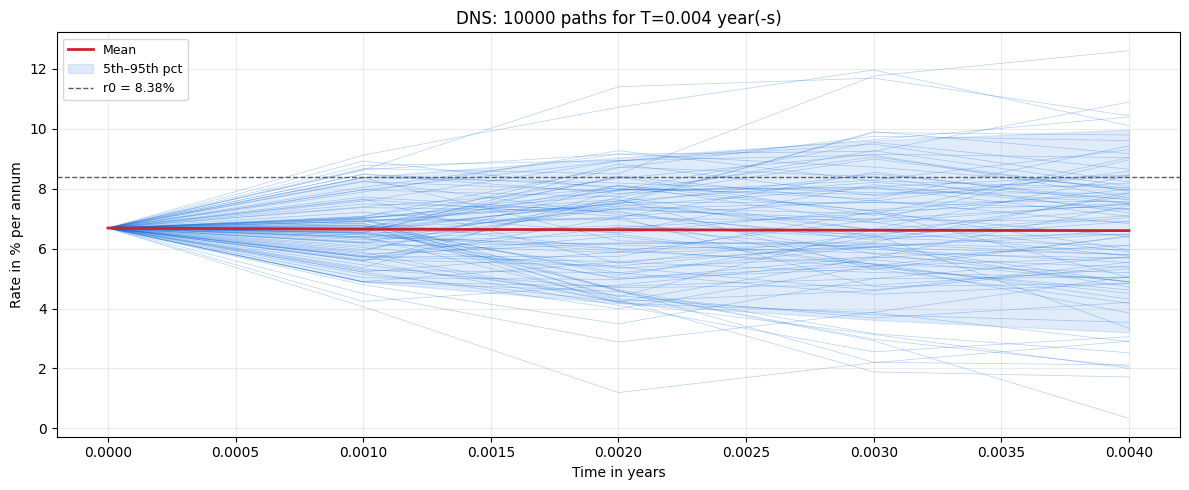

In [18]:
paths_dns = dns.simulate(T=T, dt=DT, n_paths=NPATHS, n_show=100)

### Classical Models: Backtest

In [19]:
CL = [0.05, 0.01]
DT = 1/(250 * 5) # 1/5 of day to have a simulation inside a day
T = 1/250 # 1 business day

full_series = ROISFIX.yield_matrix(dropna=False)['1M']
test_dates = test.index.tolist()

tenors_dns = list(train.columns)
full_matrix = ROISFIX.yield_matrix(dropna=False)[tenors_dns]

bt = {name: {level: [] for level in CL} for name in ['vasicek', 'hull-white']}

print(f'Test period: from {test_dates[0].date()} to {test_dates[-1].date()}, Overall: {len(test_dates)} observations')

Test period: from 2023-01-09 to 2026-04-22, Overall: 815 observations


In [20]:
for idx, t in enumerate(test_dates[:-1]):
    next_t = test_dates[idx + 1]
    r_now = full_series.loc[t] # rate today
    r_tom = full_series.loc[next_t] # rate tomorrow

    if pd.isna(r_now) or pd.isna(r_tom):
        continue

    # Vasicek — только r0
    vasicek.params['r0'] = r_now
    sim_df = vasicek.simulate(T=T, dt=DT, n_paths=NPATHS, plot=False, seed=idx)
    last_row = sim_df.iloc[-1].values
    for conf_level in CL:
        quantile = np.quantile(last_row, conf_level)
        bt['vasicek'][conf_level].append(int(r_tom < quantile))

    # Hull-White 
    hw_window = 250 * 2 # 2 years
    calib_hw = full_series.loc[:t].dropna().tail(hw_window) # 2 year window of rate
    hw_local = ClassicModel('hull-white').calibrate(calib_hw, dt=1/250) # calibration on look-back window for theta_t parameter
    
    hw_local.params['r0'] = r_now # starting rate
    sim_df = hw_local.simulate(T=T, dt=DT, n_paths=NPATHS, plot=False, seed=idx)
    last_row = sim_df.iloc[-1].values
    for conf_level in CL:
        quantile = np.quantile(last_row, conf_level)
        bt['hull-white'][conf_level].append(int(r_tom < quantile))

In [21]:
idx_1m = tenors.index('1M')
hits_dns = {conf_level: [] for conf_level in CL}

for idx, t in enumerate(test_dates[:-1]):
    next_t = test_dates[idx + 1]
    row_now  = full_matrix.loc[t]
    row_tom = full_matrix.loc[next_t, '1M']

    if row_now.isna().any() or pd.isna(row_tom):
        continue

    dns.params['r0'] = row_now['1M']
    dns.params['beta_last'] = dns.params['beta_last'].copy() # save the original one

    curves = dns.simulate_curves(taus=maturities, T=T, dt=DT, n_paths=NPATHS, seed=idx)
    last_row = curves[-1, :, idx_1m]

    for conf_level in CL:
        quantile = np.quantile(last_row, conf_level)
        hits_dns[conf_level].append(int(row_tom < quantile))

In [22]:
df_ablation = []

for model in ['vasicek', 'hull-white']:
    row = {'model': model}
    for conf_level in CL:
        hits = bt[model][conf_level]
        level = f'{int(conf_level*100)}%'
        row[f'Hits at {level}'] = round(np.mean(hits), 3)
        row[f'Kupiec at {level}'] = round(kupiec_pof(hits, conf_level), 3)
        row[f'CC at {level}'] = round(christoffersen(hits, conf_level), 3)
    df_ablation.append(row)

row = {'model': 'dns'}
for conf_level in CL:
    hits = hits_dns[conf_level]
    level = f'{int(conf_level*100)}%'
    row[f'Hits at {level}'] = round(np.mean(hits), 3)
    row[f'Kupiec at {level}'] = round(kupiec_pof(hits, conf_level), 3)
    row[f'CC at {level}'] = round(christoffersen(hits, conf_level), 3)
df_ablation.append(row)

pd.DataFrame(df_ablation).set_index('model')

,Hits at 5%,Kupiec at 5%,CC at 5%,Hits at 1%,Kupiec at 1%,CC at 1%
model,,,,,,
vasicek,0.006,0.0,0.804,0.005,0.106,0.842
hull-white,0.005,0.0,0.842,0.004,0.038,0.881
dns,0.162,0.0,0.000,0.162,0.000,0.000


In [23]:
kupiec_pof(hits_dns[0.05], conf_level)

1.8322024320177719e-112

### Generative Models

In [24]:
# First 6 tenors only (1Y and 2Y are sparse pre-2018)
TENORS_GEN = ['1W', '2W', '1M', '2M', '3M', '6M']
SEQ_LEN = 21 # 1 month
N_PATHS = 500
EPOCHS = 150

train_matrix = ROISFIX.df[TENORS_GEN].dropna()

print(f"Training matrix: {train_matrix.shape[0]} obs × {train_matrix.shape[1]} tenors")

Training matrix: 3708 obs × 6 tenors


In [25]:
TENOR_BT = '1M'
TENOR_IDX = TENORS_GEN.index(TENOR_BT)
CL = [0.95, 0.99]
NPATHS_BT = 1000
SPLIT = 0.8
HORIZON = SEQ_LEN # 21 trading days

n_train = int(len(train_matrix) * SPLIT)
bt_train = train_matrix.iloc[:n_train]
bt_test = train_matrix.iloc[n_train:]

print(f"Train: {len(bt_train)} obs")
print(f"Test: {len(bt_test)} obs")
print(f"Horizon: {HORIZON} business days (1 month)")

Train: 2966 obs
Test: 742 obs
Horizon: 21 business days (1 month)


In [26]:
def plot_generated(samples, tenor_idx, tenor_name, model_name, n_show=80):
    horizon = samples.shape[1]
    t_axis = np.arange(horizon)
    paths = samples[:, :, tenor_idx]
    mean_path = paths.mean(axis=0)
    p05 = np.percentile(paths, 5,  axis=0)
    p95 = np.percentile(paths, 95, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # left plot: path fan
    ax = axes[0]
    for i in range(min(n_show, len(paths))):
        ax.plot(t_axis, paths[i], linewidth=0.4, alpha=0.25, color='blue')
    
    ax.plot(t_axis, mean_path, linewidth=2, color='red', label='Mean')
    ax.fill_between(t_axis, p05, p95, alpha=0.15, color='blue', label='5th–95th pct')
    ax.set_title(f'{model_name}: simulated paths ({tenor_name})')
    ax.set_xlabel('Business days')
    ax.set_ylabel('Rate in % per annum')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

    # right plot: cross-sectional yield curves at the final step
    ax = axes[1]
    final_curves = samples[:, -1, :]
    x_pos = np.arange(len(TENORS_GEN))
    
    ax.fill_between(x_pos, np.percentile(final_curves, 5,  axis=0), np.percentile(final_curves, 95, axis=0), alpha=0.20, color='blue', label='5th–95th pct')
    ax.plot(x_pos, final_curves.mean(axis=0), color='red', linewidth=2, label='Mean')
    ax.plot(x_pos, train_matrix.iloc[-1].values, color='grey', linewidth=1.5, linestyle='--', label='Last observed')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(TENORS_GEN)
    ax.set_title(f'{model_name}: yield curve distribution at horizon end')
    ax.set_xlabel('Tenor')
    ax.set_ylabel('Rate in % per annum')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_loss(history, model_name):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(history['train_loss'], label='Train loss', color='blue')
    
    if any(v == v for v in history['val_loss']):
        ax.plot(history['val_loss'], label='Val loss', color='red', linestyle='--')
    
    ax.set_title(f'{model_name}: training loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    
    plt.tight_layout()
    plt.show()

#### VAE

VAE: epoch   1/150 | train=0.310769 | val=0.715672
VAE: epoch   8/150 | train=0.046992 | val=0.194735
VAE: epoch  15/150 | train=0.043343 | val=0.175886
VAE: epoch  22/150 | train=0.041963 | val=0.177859
VAE: epoch  29/150 | train=0.042071 | val=0.172299
VAE: epoch  36/150 | train=0.041118 | val=0.169404
VAE: epoch  43/150 | train=0.041173 | val=0.170514
VAE: epoch  50/150 | train=0.041031 | val=0.169272
VAE: epoch  57/150 | train=0.040551 | val=0.166952
VAE: epoch  64/150 | train=0.040722 | val=0.164375
VAE: epoch  71/150 | train=0.040746 | val=0.163146
VAE: epoch  78/150 | train=0.040895 | val=0.164601
VAE: epoch  85/150 | train=0.040521 | val=0.163825
VAE: epoch  92/150 | train=0.040523 | val=0.162868
VAE: epoch  99/150 | train=0.040841 | val=0.162944
VAE: epoch 106/150 | train=0.040567 | val=0.162463
VAE: epoch 113/150 | train=0.040524 | val=0.162029
VAE: epoch 120/150 | train=0.040662 | val=0.160836
VAE: epoch 127/150 | train=0.040311 | val=0.161502
VAE: epoch 134/150 | train=0.04

architecture,Varitaional Autoencoder
device,cuda
seq_len,21
n_tenors,6
n_parameters,"29,654"
epochs_run,150
final train loss,0.040151
best val loss,0.158807


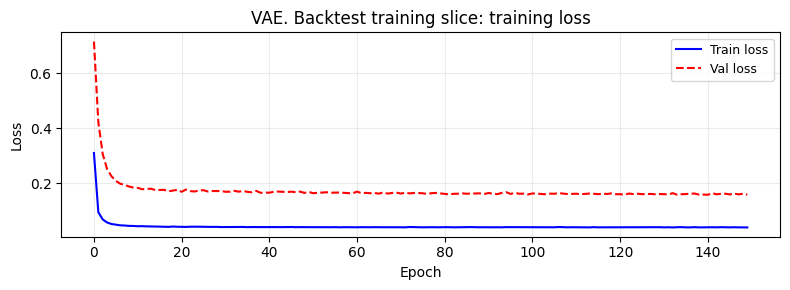

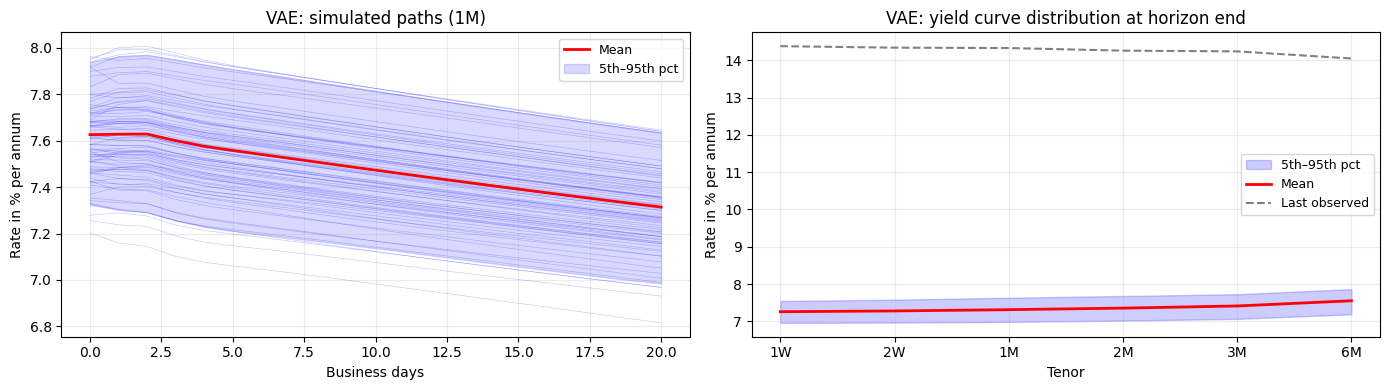

In [27]:
from src.generative_models import VAEModel

vae = VAEModel(seq_len=SEQ_LEN, n_tenors=6, hidden=64, latent=8)
vae.fit(bt_train, epochs=EPOCHS, batch_size=64, verbose=True)
vae.display_training_info()
plot_loss(vae.history, 'VAE. Backtest training slice')

vae_samples = vae.generate(n_samples=N_PATHS)
plot_generated(vae_samples, tenor_idx=2, tenor_name='1M', model_name='VAE')

#### NeuralSDE

NeuralSDE: epoch   1/150 | train=0.499515 | val=1.319658
NeuralSDE: epoch   8/150 | train=0.146901 | val=0.715881
NeuralSDE: epoch  15/150 | train=0.113749 | val=0.570229
NeuralSDE: epoch  22/150 | train=0.109384 | val=0.541680
NeuralSDE: epoch  29/150 | train=0.107733 | val=0.516832
NeuralSDE: epoch  36/150 | train=0.104723 | val=0.505300
NeuralSDE: epoch  43/150 | train=0.105299 | val=0.486346
NeuralSDE: epoch  50/150 | train=0.102956 | val=0.496434
NeuralSDE: epoch  57/150 | train=0.102928 | val=0.464755
NeuralSDE: epoch  64/150 | train=0.102223 | val=0.463087
NeuralSDE: epoch  71/150 | train=0.103028 | val=0.459440
NeuralSDE: epoch  78/150 | train=0.101750 | val=0.458889
NeuralSDE: epoch  85/150 | train=0.099639 | val=0.440494
NeuralSDE: epoch  92/150 | train=0.106123 | val=0.441924
NeuralSDE: epoch  99/150 | train=0.099196 | val=0.425737
NeuralSDE: epoch 106/150 | train=0.098832 | val=0.420471
NeuralSDE: epoch 113/150 | train=0.098176 | val=0.427513
NeuralSDE: epoch 120/150 | trai

architecture,Neural Stochastic Differntial Equation
device,cuda
seq_len,21
n_tenors,6
n_parameters,"3,870"
epochs_run,150
final train loss,0.097615
best val loss,0.384190


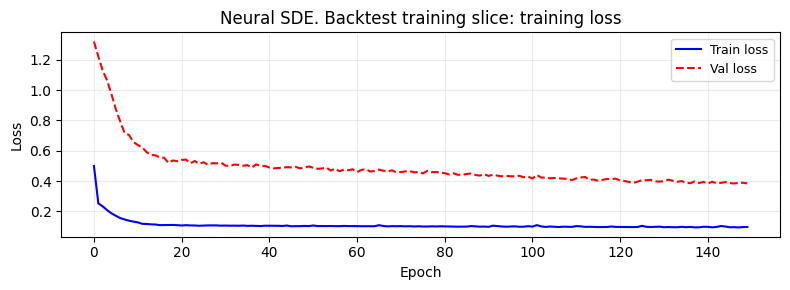

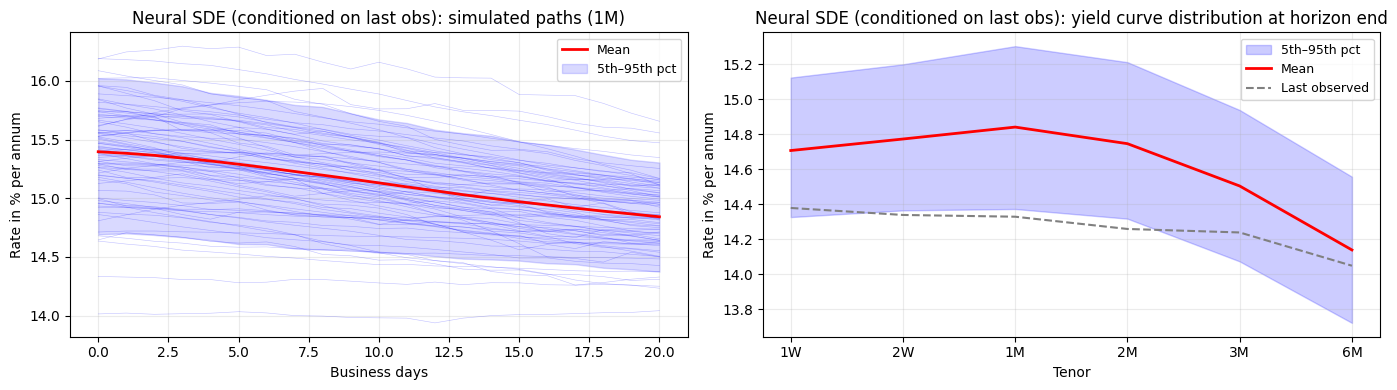

In [28]:
from src.generative_models import NeuralSDEModel

nsde = NeuralSDEModel(seq_len=SEQ_LEN, n_tenors=6, latent_dim=6, hidden=64)
nsde.fit(bt_train, epochs=EPOCHS, batch_size=64, dt=1/250, verbose=True)
nsde.display_training_info()


last_obs = train_matrix.iloc[-1].values # conditional on the last observed yield curve
nsde_samples_cond = nsde.generate(n_samples=N_PATHS, horizon=SEQ_LEN, dt=1/250, init_yields=last_obs)

plot_loss(nsde.history, 'Neural SDE. Backtest training slice')
plot_generated(nsde_samples_cond, tenor_idx=2, tenor_name='1M', model_name='Neural SDE (conditioned on last obs)')

In [29]:
import os
os.makedirs('data/checkpoints', exist_ok=True)

vae.save('data/checkpoints/vae.pt')
nsde.save('data/checkpoints/nsde.pt')

print('Checkpoints saved')

Checkpoints saved


### Generative Models: Backtest

In [30]:
hits_vae = run_horizon_backtest(vae,  bt_test, TENOR_IDX, CL, horizon=HORIZON, n_paths=NPATHS_BT, use_init=False)
hits_nsde = run_horizon_backtest(nsde, bt_test, TENOR_IDX, CL, horizon=HORIZON, n_paths=NPATHS_BT, use_init=True)

print(f'Done: {len(bt_test) - HORIZON} test observations.')

Done: 721 test observations.


In [31]:
def backtest_table(hits_dict, model_name, conf_levels):
    row = {'model': model_name}
    
    for cl in conf_levels:
        hits = hits_dict[cl]
        label = f'{int((1-cl) * 100)}%'
        
        row[f'Hits at {label}'] = round(np.mean(hits), 4)
        row[f'Kupiec {label}'] = round(kupiec_pof(hits, cl), 3)
        row[f'CC {label}'] = round(christoffersen(hits, cl), 3)
    
    return row

rows = [backtest_table(hits_vae, 'vae', CL), backtest_table(hits_nsde, 'neural sde', CL)]

pd.DataFrame(rows).set_index('model')

,Hits at 5%,Kupiec 5%,CC 5%,Hits at 1%,Kupiec 1%,CC 1%
model,,,,,,
vae,0.0388,0.0,0.0,0.0416,0.0,0.0
neural sde,0.5492,0.0,0.0,0.5687,0.0,0.0


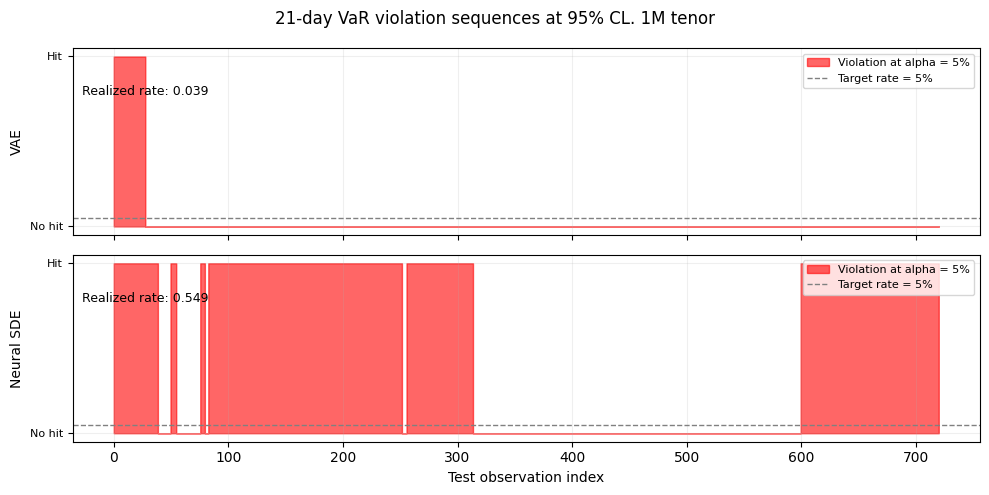

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for ax, hits_dict, label in zip(axes, [hits_vae, hits_nsde], ['VAE', 'Neural SDE']):
    hits_arr = np.array(hits_dict[0.95])
    t_axis   = np.arange(len(hits_arr))

    ax.fill_between(t_axis, hits_arr, step='mid', alpha=0.6, color='red', label='Violation at alpha = 5%')
    ax.axhline(0.05, color='grey', linewidth=1, linestyle='--', label='Target rate = 5%')
    ax.text(0.01, 0.75, f"Realized rate: {np.mean(hits_arr):.3f}", transform=ax.transAxes, fontsize=9, color='black')
    ax.set_ylabel(label, fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['No hit', 'Hit'], fontsize=8)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Test observation index')
fig.suptitle(f'{HORIZON}-day VaR violation sequences at 95% CL. {TENOR_BT} tenor', fontsize=12)
plt.tight_layout()
plt.show()

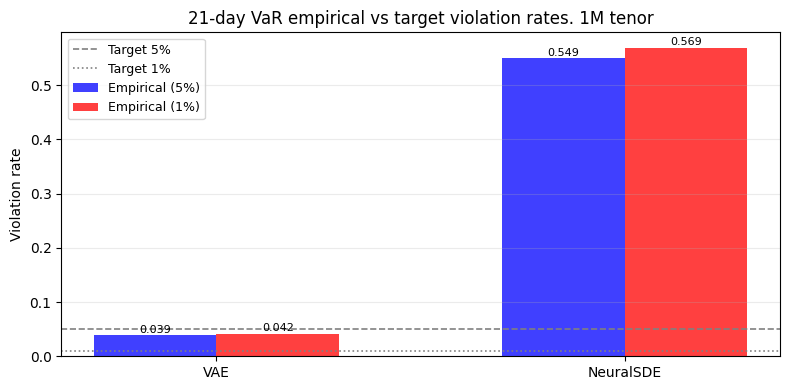

In [33]:
fig, ax = plt.subplots(figsize=(8, 4))

models = ['VAE', 'NeuralSDE']
x = np.arange(len(models))
width = 0.3

for i, cl in enumerate(CL):
    emp_rates = [
        np.mean(hits_vae[cl]),
        np.mean(hits_nsde[cl]),
    ]
    bars = ax.bar(x + i * width, emp_rates, width, label=f'Empirical ({int((1-cl)*100)}%)', color=['blue', 'red'][i], alpha=0.75)
    for bar, val in zip(bars, emp_rates):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

for cl, ls in zip(CL, ['--', ':']):
    ax.axhline(1 - cl, color='grey', linewidth=1.2, linestyle=ls, label=f'Target {int((1-cl)*100)}%')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(models)
ax.set_ylabel('Violation rate')
ax.set_title(f'{HORIZON}-day VaR empirical vs target violation rates. {TENOR_BT} tenor')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='y')
plt.tight_layout()
plt.show()